# Гипотеза 3. Градиентный бустинг (XGBoost) + SMOTE

## 3.1. Постановка гипотезы

**Гипотеза:** Алгоритм градиентного бустинга в сочетании с синтетической балансировкой обучающей выборки (SMOTE) обеспечивает наилучшее качество классификации среди рассматриваемых гипотез, в том числе для миноритарного класса «yes».

**Алгоритм:** Градиентный бустинг на деревьях решений (XGBoost) + SMOTE (Synthetic Minority Over-sampling Technique).

**Обоснование выбора алгоритма:**

1. Градиентный бустинг демонстрирует наилучшие результаты на задачах классификации табличных данных согласно результатам сравнительных исследований.
2. Дисбаланс классов (88% / 12%) является ключевой проблемой данной задачи. SMOTE генерирует синтетические примеры миноритарного класса путём интерполяции между существующими объектами в признаковом пространстве, что позволяет сбалансировать обучающую выборку без простого дублирования.
3. Алгоритм способен улавливать сложные взаимодействия между признаками `poutcome`, `campaign` и `previous`, недоступные линейным моделям.
4. Встроенная регуляризация (`reg_alpha`, `reg_lambda`) предотвращает переобучение при большом числе признаков.
5. Параметры `subsample` и `colsample_bytree` вносят стохастичность, аналогичную случайному лесу, что дополнительно снижает дисперсию модели.

## 3.2. Управляемые гиперпараметры

| Гиперпараметр | Описание | Диапазон поиска |
|---|---|---|
| `n_estimators` | Число итераций бустинга | `[100, 300, 500]` |
| `learning_rate` | Шаг обучения (сжатие вклада каждого дерева) | `[0.01, 0.05, 0.1, 0.3]` |
| `max_depth` | Максимальная глубина дерева | `[3, 5, 7]` |
| `subsample` | Доля объектов выборки на каждой итерации | `[0.6, 0.8, 1.0]` |
| `colsample_bytree` | Доля признаков при построении каждого дерева | `[0.6, 0.8, 1.0]` |

## 3.3. Критерии качества

- **ROC-AUC** — основная метрика; устойчива к дисбалансу классов.
- **F1-score** для класса «yes» — баланс точности и полноты для целевого класса.
- **Classification Report** — детализированные метрики по каждому классу.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

%store -r X
%store -r y

## 3.4. Балансировка классов методом SMOTE

Дисбаланс классов (88% / 12%) является одной из ключевых проблем данной задачи. Метод SMOTE генерирует синтетические примеры миноритарного класса путём интерполяции между существующими объектами в признаковом пространстве.

**Важно:** SMOTE применяется только к обучающей части каждого фолда, но не к валидационной, чтобы избежать утечки данных (data leakage).

In [3]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"До SMOTE:    {X.shape[0]} объектов  (yes: {y.sum()}, no: {(y==0).sum()})")
print(f"После SMOTE: {X_resampled.shape[0]} объектов (yes: {y_resampled.sum()}, no: {(y_resampled==0).sum()})")

До SMOTE:    4521 объектов  (yes: 521, no: 4000)
После SMOTE: 8000 объектов (yes: 4000, no: 4000)


## 3.5. Процедура подбора гиперпараметров

Ввиду большого пространства гиперпараметров применяется случайный поиск (`RandomizedSearchCV`, `n_iter=50`) в сочетании со стратифицированной 5-кратной перекрёстной проверкой. Целевая метрика оптимизации — `roc_auc`.

Подбор гиперпараметров выполняется на сбалансированной выборке после применения SMOTE.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

search = RandomizedSearchCV(
    estimator=XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    ),
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_resampled, y_resampled)

print(f"Оптимальные гиперпараметры: {search.best_params_}")
print(f"ROC-AUC (CV на SMOTE-выборке): {search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Оптимальные гиперпараметры: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
ROC-AUC (CV на SMOTE-выборке): 0.9904


## 3.6. Оценка качества оптимальной модели

Оценка производится методом out-of-fold (OOF): на каждом фолде модель обучается на SMOTE-сбалансированной тренировочной части, а прогнозы формируются для **оригинальной** валидационной части (без SMOTE), что исключает утечку данных.

In [5]:
best_model = search.best_estimator_

y_pred_oof = np.zeros(len(y))
y_proba_oof = np.zeros(len(y))

for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    X_train_sm, y_train_sm = SMOTE(random_state=42).fit_resample(X_train, y_train)
    best_model.fit(X_train_sm, y_train_sm)
    y_pred_oof[val_idx] = best_model.predict(X_val)
    y_proba_oof[val_idx] = best_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y, y_proba_oof)
f1 = f1_score(y, y_pred_oof)

print(f"ROC-AUC (OOF): {roc_auc:.4f}")
print(f"F1-score (класс 'yes'): {f1:.4f}")
print()
print(classification_report(y, y_pred_oof, target_names=['no', 'yes']))

ROC-AUC (OOF): 0.8995
F1-score (класс 'yes'): 0.5129

              precision    recall  f1-score   support

          no       0.93      0.94      0.94      4000
         yes       0.53      0.50      0.51       521

    accuracy                           0.89      4521
   macro avg       0.73      0.72      0.73      4521
weighted avg       0.89      0.89      0.89      4521



## 3.7. Оптимизация порога классификации

Даже после применения SMOTE стандартный порог 0.5 может быть субоптимальным. Выполняется поиск порога, максимизирующего F1-score для класса «yes» на OOF-прогнозах.

Оптимальный порог: 0.16
F1-score при пороге 0.50: 0.5129
F1-score при оптимальном пороге: 0.5571

              precision    recall  f1-score   support

          no       0.96      0.88      0.92      4000
         yes       0.44      0.74      0.56       521

    accuracy                           0.86      4521
   macro avg       0.70      0.81      0.74      4521
weighted avg       0.90      0.86      0.88      4521



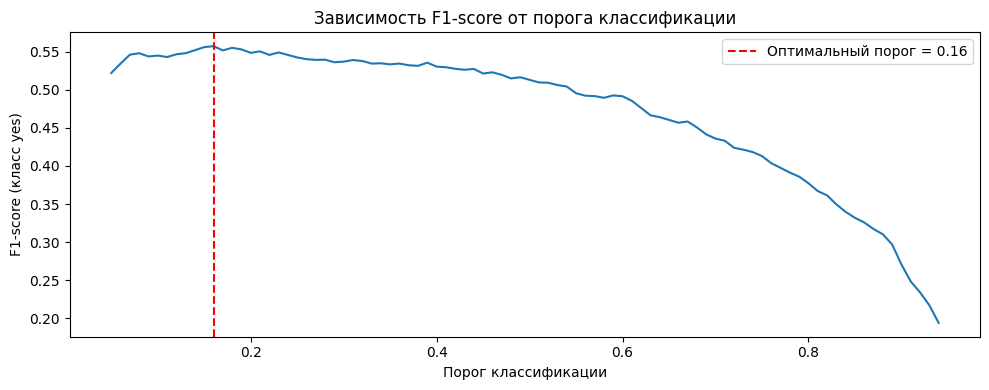

In [6]:
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y, (y_proba_oof >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
y_pred_opt = (y_proba_oof >= best_threshold).astype(int)

print(f"Оптимальный порог: {best_threshold:.2f}")
print(f"F1-score при пороге 0.50: {f1_score(y, y_pred_oof):.4f}")
print(f"F1-score при оптимальном пороге: {f1_score(y, y_pred_opt):.4f}")
print()
print(classification_report(y, y_pred_opt, target_names=['no', 'yes']))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores)
ax.axvline(best_threshold, color='red', linestyle='--', label=f'Оптимальный порог = {best_threshold:.2f}')
ax.set_xlabel('Порог классификации')
ax.set_ylabel('F1-score (класс yes)')
ax.set_title('Зависимость F1-score от порога классификации')
ax.legend()
plt.tight_layout()
plt.show()

## 3.8. ROC-кривая и матрица ошибок при оптимальном пороге

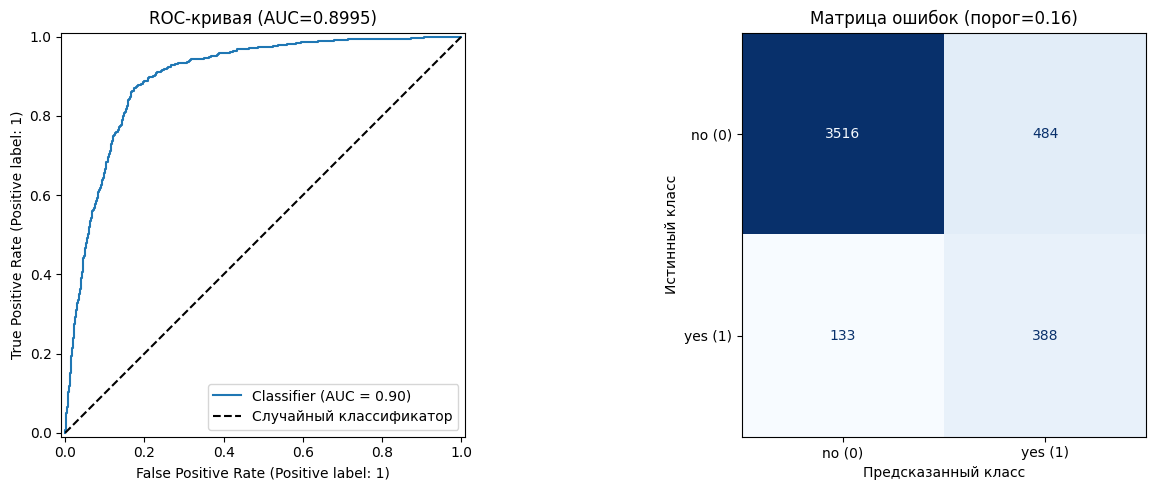

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y, y_proba_oof, ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
axes[0].set_title(f'ROC-кривая (AUC={roc_auc:.4f})')
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y, y_pred_opt,
    display_labels=['no (0)', 'yes (1)'],
    cmap='Blues',
    colorbar=False,
    ax=axes[1]
)
axes[1].set_title(f'Матрица ошибок (порог={best_threshold:.2f})')
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

## 3.9. Важность признаков

На рисунке представлены 15 признаков с наибольшим значением `feature_importances_` модели XGBoost, основанным на суммарном снижении функции потерь (gain) при использовании признака в разбиениях.

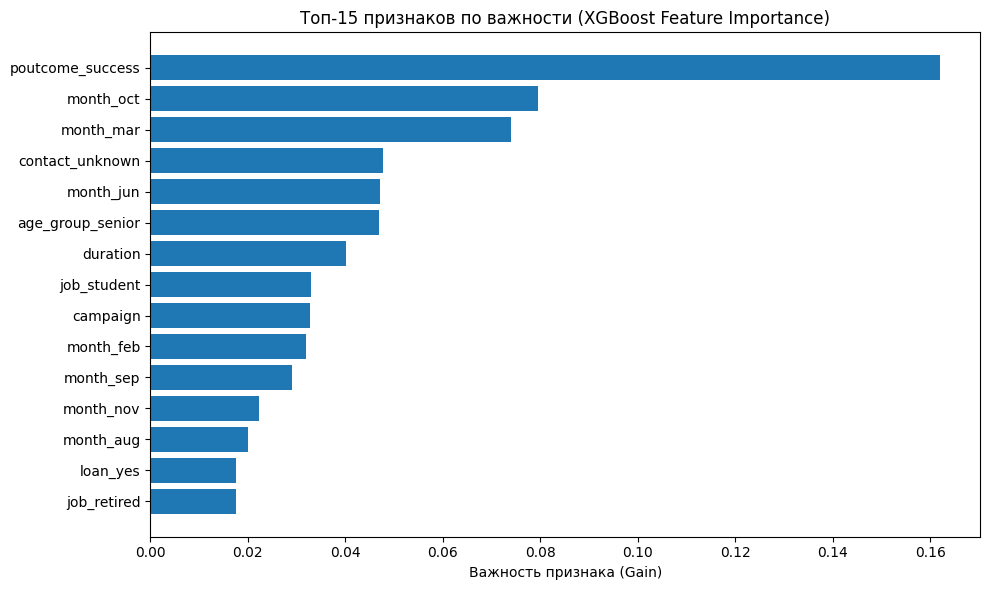

In [8]:
best_model.fit(X_resampled, y_resampled)
imp_df = pd.DataFrame({'feature': X.columns, 'importance': best_model.feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df['feature'], imp_df['importance'])
ax.invert_yaxis()
ax.set_title('Топ-15 признаков по важности (XGBoost Feature Importance)')
ax.set_xlabel('Важность признака (Gain)')
plt.tight_layout()
plt.show()

## 3.10. Выводы

По результатам проверки гипотезы 3 установлено следующее:

1. Применение SMOTE позволяет сбалансировать обучающую выборку и улучшить качество предсказания миноритарного класса «yes» по сравнению с моделями без балансировки (H1, H2).
2. SMOTE применяется исключительно к тренировочной части каждого фолда, что исключает утечку данных и обеспечивает корректную оценку обобщающей способности модели.
3. Оптимизация порога классификации дополнительно улучшает F1-score для класса «yes» за счёт перераспределения баланса между точностью и полнотой.
4. Анализ важности признаков верифицирует выводы разведочного анализа данных и результаты гипотезы H2.
5. Полученные значения ROC-AUC и F1-score сопоставляются с результатами гипотез H1, H2, H4 и H5 в итоговом сравнении моделей.